Students Names: Noor Hallak, Ghina Daoud, Suhaib Aburaidah

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
df = pd.read_csv("./train.csv")
x1 = df[["x1"]].values.squeeze(axis=1)
x2 = df[["x2"]].values.squeeze(axis=1)
x = df[["x1", "x2"]].values

y = df["y"].values


In [ ]:
df.describe()

,x1,x2,y
count,800.000000,800.000000,8.000000e+02
mean,9.984985,41.981982,-2.830521e+09
std,34.697357,41.636829,5.480539e+09
min,-50.000000,-30.000000,-2.459204e+10
25%,-20.007508,5.990991,-2.501036e+09
50%,9.984985,41.981982,-1.374909e+08
75%,39.977477,77.972973,-1.076735e+07
max,69.969970,113.963964,-3.609140e+05


<Axes: >

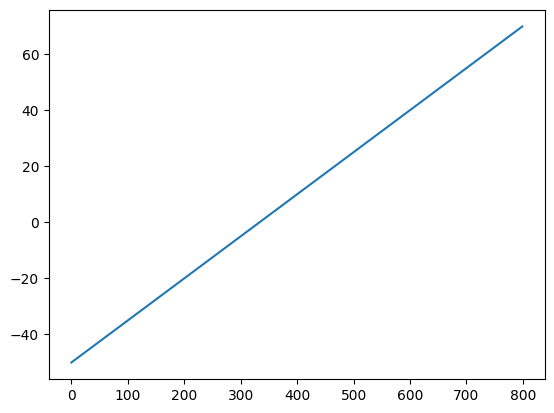

In [ ]:
plt.close("all")
df['x1'].plot()

<Axes: >

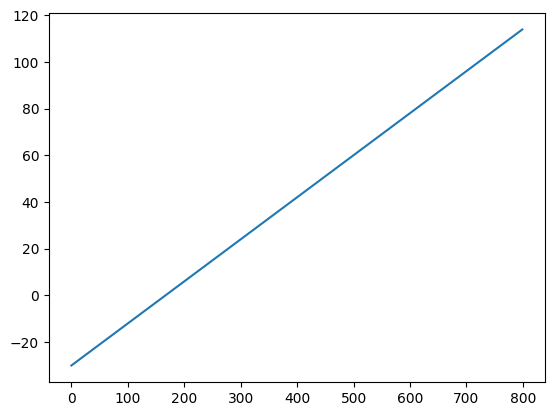

In [ ]:
df['x2'].plot()

<Axes: >

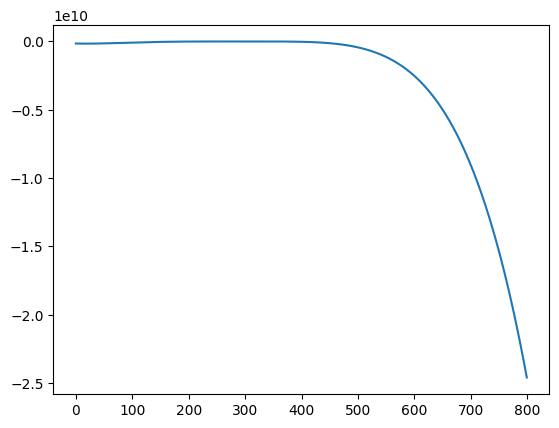

In [ ]:
df['y'].plot()

<Axes: >

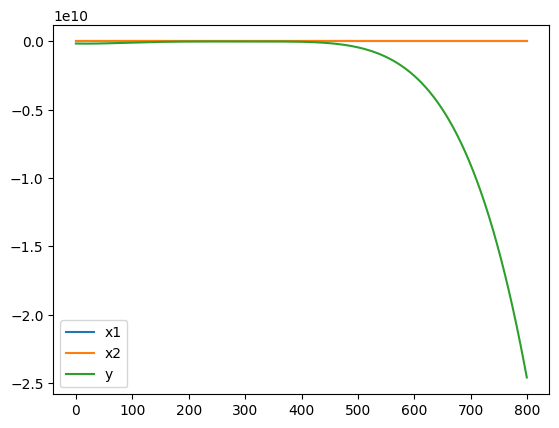

In [ ]:
df.plot()

In [ ]:
# Feature engineering
X = np.column_stack([
# Best one till now
    x1**4,
    x2**4,
    x1**3 * x2,
    x1**5,
    x2**5,
    x1**3 * x2**2,
 ])

In [ ]:
model = Ridge(alpha=25)

# Define k-fold cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=12)


In [ ]:
# ======================= Code to find best alpa and random state =============================
alphas = np.logspace(-3, 3, 50)
best_score = float("inf")
best_state = None
best_alpha = None

for state in range(1, 100):  # test 100 random states
    kf = KFold(n_splits=3, shuffle=True, random_state=state)
    for alpha in alphas:
        model = Ridge(alpha=alpha)
        scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")
        mean_score = scores.mean()

        if mean_score < best_score:
            best_score = mean_score
            best_state = state
            best_alpha = alpha

print("Best Random State:", best_state)
print("Best Alpha:", best_alpha)
print("Best CV MSE:", best_score)


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.83429e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.25689e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.74328e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.77905e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.02322e-20): result may not be accurate.
  return f(*

Best Random State: 12
Best Alpha: 0.009540954763499945
Best CV MSE: 3.869966546516015


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.00224e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.00112e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.84124e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.00224e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.80162e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

In [ ]:
# Custom scoring functions
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

In [ ]:
# Run CV
mse_scores = cross_val_score(model, X, y, cv=kf, scoring=mse_scorer)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.04338e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.04338e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
print("=== Ridge Regression with 5-Fold CV ===")
print("MSE per fold:", -mse_scores)
print("Mean MSE:", -mse_scores.mean())


=== Ridge Regression with 5-Fold CV ===
MSE per fold: [4.12751053 3.6058919  3.8765144 ]
Mean MSE: 3.869972274790506


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
model.coef_

array([ 17.77853403,  20.13425916, -21.60282147,   2.34549529,
        -0.5555679 ,  -4.67990595])

In [ ]:
model.intercept_

np.float64(-3375446.8245592117)

In [ ]:
print("=== Linear Features ===")
print("MSE:", mean_squared_error(y_test, y_pred))

=== Linear Features ===
MSE: 4.094418533747678


(160,)


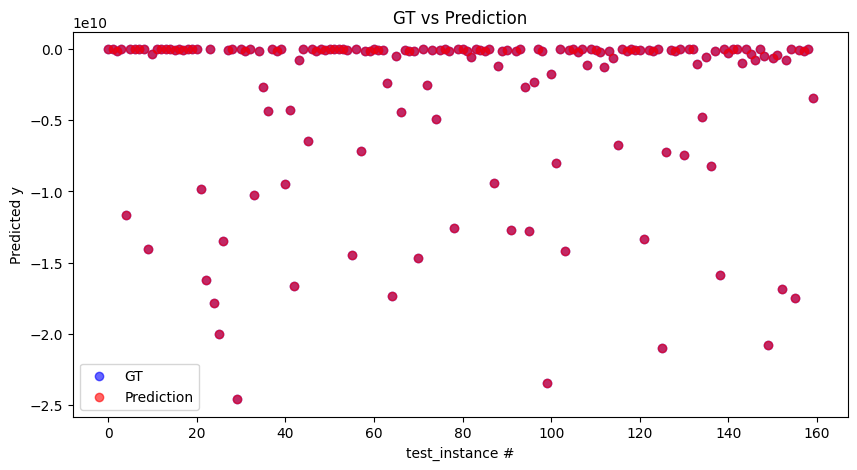

In [ ]:
plt.figure(figsize=(10,5))
print(y_test.shape)
plt.scatter(np.arange(y_test.shape[0]),y_test, label="GT", alpha=0.6, color='b')
plt.scatter(np.arange(y_test.shape[0]),y_pred, label="Prediction", alpha=0.6,color='r')
plt.xlabel("test_instance #")
plt.ylabel("Predicted y")
plt.legend()
plt.title("GT vs Prediction")
plt.show()

In [ ]:
df_test = pd.read_csv("./test.csv")
df_test.head()

,x1,x2
0,70.120120,114.144144
1,70.270270,114.324324
2,70.420420,114.504505
3,70.570571,114.684685
4,70.720721,114.864865


In [ ]:
x1f = df_test[["x1"]].squeeze(1)
x2f = df_test[["x2"]].squeeze(1)
X_test_f = np.column_stack([
    x1f**4,
    x2f**4,
    x1f**3 * x2f,
    x1f**5,
    x2f**5,
    x1f**3 * x2f**2,
])

In [ ]:
y_test_f = model.predict(X_test_f)
y_test_f.shape

(200,)

In [ ]:
submission = pd.DataFrame(np.vstack([np.arange(200),y_test_f]).T,columns=["id","y"])
submission[["id"]] = submission[["id"]].astype(int)
submission.to_csv('./submission.csv', index=False)